<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_V32_EXECUTED_Parent_Action_Origin_of_Universal_Matter_Coupling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM V32 — Parent-Action Origin of Universal Matter Coupling

V31.1 established that the radial packet response is exactly universal whenever the sector-response vector lies in the equivalence class

\[
w=a\mathbf 1+b\,c_{\rm EOM},
\qquad
c_{\rm EOM}=(1,-1,1,2,3).
\]

The equal-weight representative

\[
w=a\mathbf 1
\]

corresponds to a common multiplicative response of the complete packet energy density.

V32 asks whether that structure follows naturally from a parent condensate action.

We test the hypothesis that the matter sector appears in the parent action through one scalar response factor,

\[
S_{\rm matter}
=
\int d^4x\,
\mathcal A(q)\,
\mathcal L_0[\Psi],
\]

with

\[
\mathcal A(q)=e^{\zeta_0 q}.
\]

Then

\[
\frac{\partial \mathcal L_{\rm matter}}{\partial q}
=
\zeta_0\mathcal L_{\rm matter},
\]

so the full on-shell packet energy obeys

\[
\frac{1}{E_{\rm on}}
\frac{dE_{\rm on}}{dq}
=
\zeta_0
\]

independently of charge, radius, profile, or internal energy partition.

This notebook:

1. derives the common-factor result symbolically;
2. shows that equation-of-motion deformations are on-shell redundant;
3. rebuilds the radial packet family;
4. verifies exact universality numerically for the parent-action coupling;
5. verifies that non-common couplings reintroduce composition dependence;
6. connects the result to the ECSM gravitational coupling formula.

## Claim boundary

This demonstrates that a single parent-action response factor is sufficient to enforce exact universality. It does not yet derive the numerical value of \(\zeta_0\), \(C\), or \(K_q\) from deeper condensate microphysics.

## 1. Imports and outputs

In [ ]:
from pathlib import Path
import json, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp
from scipy.integrate import solve_bvp, simpson

BASE = Path('/content') if Path('/content').exists() else Path('/mnt/data')
OUT = BASE/'ecsm_v32_out'
FIG = OUT/'figures'
TAB = OUT/'tables'
for p in [OUT,FIG,TAB]:
    p.mkdir(parents=True,exist_ok=True)

summary=[]
print('Output directory:',OUT)

Output directory: /mnt/data/ecsm_v32_out


## 2. Symbolic parent-action derivation

Let the unperturbed packet energy be

\[
E_0=\sum_i E_i.
\]

A common parent-action response gives

\[
E(q)=e^{\zeta_0 q}E_0.
\]

Therefore

\[
\left.\frac{dE}{dq}\right|_{q=0}
=
\zeta_0E_0.
\]

In [ ]:
q,zeta0=sp.symbols('q zeta0', real=True)
E_symbols=sp.symbols('E0:5', real=True)
E0=sum(E_symbols)
Eq=sp.exp(zeta0*q)*E0
dEq0=sp.simplify(sp.diff(Eq,q).subs(q,0))
ratio=sp.simplify(dEq0/E0)

print('dE/dq at q=0 =',dEq0)
print('(1/E)dE/dq =',ratio)

summary += [
 {'test':'symbolic_common_factor_derivative','value':str(dEq0),
  'criterion':'zeta0 * total energy','pass':sp.simplify(dEq0-zeta0*E0)==0},
 {'test':'symbolic_universal_fractional_response','value':str(ratio),
  'criterion':'= zeta0','pass':sp.simplify(ratio-zeta0)==0}
]

dE/dq at q=0 = zeta0*(E0 + E1 + E2 + E3 + E4)
(1/E)dE/dq = zeta0


## 3. Symbolic on-shell redundancy

The radial packet field equation implies

\[
E_{\rm grad}
-
E_{\rm phase}
+
E_{\rm mass}
+
2E_{\rm quartic}
+
3E_{\rm sextic}
=0.
\]

Hence a deformed response vector

\[
w=a\mathbf 1+b\,c_{\rm EOM}
\]

gives

\[
\sum_iw_iE_i
=
aE+b(c_{\rm EOM}\cdot E)
=
aE.
\]

In [ ]:
a,b=sp.symbols('a b', real=True)
Eg,Ep,Em,E4,E6=sp.symbols('Eg Ep Em E4 E6', real=True)
Et=Eg+Ep+Em+E4+E6
eom=Eg-Ep+Em+2*E4+3*E6

weighted=(
    (a+b)*Eg
    +(a-b)*Ep
    +(a+b)*Em
    +(a+2*b)*E4
    +(a+3*b)*E6
)

reduced=sp.simplify(weighted.subs(Eg,Ep-Em-2*E4-3*E6))
target=sp.simplify((a*Et).subs(Eg,Ep-Em-2*E4-3*E6))

summary += [
 {'test':'symbolic_eom_equivalence_class','value':str(sp.simplify(reduced-target)),
  'criterion':'=0','pass':sp.simplify(reduced-target)==0}
]

print('weighted response on shell =',reduced)
print('a times total energy =',target)

weighted response on shell = a*(-E4 - 2*E6 + 2*Ep)
a times total energy = a*(-E4 - 2*E6 + 2*Ep)


## 4. Radial packet model

In [ ]:
P={'m2':1.0,'lam':2.0,'kap':1.0,'rmin':1e-5,'rmax':40.0,'nmesh':700}

def rhs(r,y,w,p=P):
    f,fp=y
    rr=np.maximum(r,p['rmin'])
    fpp=(p['m2']-w[0]**2)*f-p['lam']*f**3+p['kap']*f**5-2*fp/rr
    return np.vstack((fp,fpp))

def bc(ya,yb,w,fc):
    return np.array([ya[1],ya[0]-fc,yb[0]])

def seed(fc,p=P,prev=None):
    if prev is not None:
        r=prev.x
        y=prev.y.copy()
        y*=fc/max(abs(y[0,0]),1e-12)
        return r,y,prev.p.copy()
    r=np.linspace(p['rmin'],p['rmax'],p['nmesh'])
    R0=5.0
    f=fc/np.cosh(r/R0)
    fp=-(fc/R0)*np.sinh(r/R0)/np.cosh(r/R0)**2
    return r,np.vstack((f,fp)),np.array([0.82])

def solve_fc(fc,p=P,prev=None,tol=2e-5):
    r,y,w=seed(fc,p,prev)
    return solve_bvp(
        lambda r,y,w:rhs(r,y,w,p),
        lambda ya,yb,w:bc(ya,yb,w,fc),
        r,y,p=w,tol=tol,max_nodes=50000
    )

def obs(sol,p=P,n=3500):
    r=np.linspace(p['rmin'],p['rmax'],n)
    f,fp=sol.sol(r)
    w=float(sol.p[0])
    dens={
      'E_grad':0.5*fp**2,
      'E_phase':0.5*w**2*f**2,
      'E_mass':0.5*p['m2']*f**2,
      'E_quartic':-0.25*p['lam']*f**4,
      'E_sextic':(p['kap']/6.0)*f**6
    }
    vals={k:4*np.pi*simpson(v*r**2,x=r) for k,v in dens.items()}
    E=sum(vals.values())
    Q=4*np.pi*w*simpson(f**2*r**2,x=r)
    norm=simpson(f**2*r**2,x=r)
    rrms=np.sqrt(simpson(f**2*r**4,x=r)/norm)
    return {**vals,'E':E,'Q':Q,'omega':w,'rrms':rrms,
            'f0':float(f[0]),'fend':float(f[-1])}

## 5. Rebuild the continuous packet branch

In [ ]:
fc_grid=np.linspace(0.15,0.72,80)
rows=[]; sols=[]; prev=None

for fc in fc_grid:
    s=solve_fc(fc,prev=prev)
    if not s.success:
        rows.append({'fc':fc,'success':False,'Q':np.nan,'localised':False})
        sols.append(None)
        continue
    o=obs(s)
    loc=abs(o['fend'])/max(abs(o['f0']),1e-30)<1e-6
    rows.append({'fc':fc,'success':True,'Q':o['Q'],'E':o['E'],
                 'omega':o['omega'],'rrms':o['rrms'],'localised':loc})
    sols.append((s,o))
    prev=s

branch=pd.DataFrame(rows)
valid=branch[branch.success & branch.localised & np.isfinite(branch.Q)].copy()
dQ=np.diff(valid.Q.to_numpy())
branch.to_csv(TAB/'01_branch.csv',index=False)

summary += [
 {'test':'branch_solution_count','value':len(valid),'criterion':'>70','pass':len(valid)>70},
 {'test':'branch_monotonicity','value':float(dQ.min()),'criterion':'>0','pass':bool(np.all(dQ>0))}
]
display(valid)

,fc,success,Q,E,omega,rrms,localised
0,0.150000,True,119.250600,120.534194,1.009059,23.105787,True
1,0.157215,True,125.309002,126.646887,1.008863,23.151235,True
2,0.164430,True,131.224285,132.614029,1.008670,23.198633,True
3,0.171646,True,137.001052,138.440333,1.008480,23.247017,True
4,0.178861,True,142.658777,144.145510,1.008293,23.296108,True
...,...,...,...,...,...,...,...
75,0.691139,True,671.609415,674.687713,0.998110,20.922930,True
76,0.698354,True,674.389343,677.462194,0.997968,20.796196,True
77,0.705570,True,676.800407,679.868192,0.997826,20.667691,True
78,0.712785,True,678.849863,681.913054,0.997685,20.537495,True


## 6. Fixed-charge packet family

In [ ]:
TARGETS=np.array([180.,240.,300.,360.,420.,480.])

def locate(target):
    idx=None
    for i in range(len(branch)-1):
        if branch.success.iloc[i] and branch.success.iloc[i+1]:
            if (branch.Q.iloc[i]-target)*(branch.Q.iloc[i+1]-target)<=0:
                idx=i; break
    if idx is None:
        raise RuntimeError(f'No crossing for Q={target}')
    i=idx
    fc1,fc2=branch.fc.iloc[i],branch.fc.iloc[i+1]
    Q1,Q2=branch.Q.iloc[i],branch.Q.iloc[i+1]
    fc=fc1+(target-Q1)*(fc2-fc1)/(Q2-Q1)
    s1=sols[i][0]; s2=sols[i+1][0]
    s=solve_fc(fc,prev=s1 if abs(fc-fc1)<=abs(fc2-fc) else s2)
    o=obs(s)
    for _ in range(5):
        resid=o['Q']-target
        if abs(resid)/target<1e-8: break
        step=max(2e-4,abs(fc)*1e-3)
        sp=solve_fc(fc+step,prev=s); sm=solve_fc(fc-step,prev=s)
        slope=(obs(sp)['Q']-obs(sm)['Q'])/(2*step)
        fc=fc-resid/slope
        s=solve_fc(fc,prev=s); o=obs(s)
    return fc,s,o

packets=[]
for target in TARGETS:
    fc,s,o=locate(float(target))
    packets.append({'Qtarget':target,'fc':fc,'success':s.success,**o})

packet_df=pd.DataFrame(packets)
packet_df.to_csv(TAB/'02_packet_family.csv',index=False)
display(packet_df[['Qtarget','Q','E','omega','rrms']])

cerr=float(np.max(np.abs(packet_df.Q-packet_df.Qtarget)/packet_df.Qtarget))
summary += [
 {'test':'all_packets_converged','value':int(packet_df.success.sum()),'criterion':'=6','pass':bool(packet_df.success.all())},
 {'test':'fixed_charge_closure','value':cerr,'criterion':'<1e-6','pass':cerr<1e-6},
 {'test':'positive_packet_energies','value':float(packet_df.E.min()),'criterion':'>0','pass':bool((packet_df.E>0).all())}
]

,Qtarget,Q,E,omega,rrms
0,180.0,180.000000,181.773918,1.007108,23.630453
1,240.0,240.000001,242.152237,1.005590,23.986681
2,300.0,300.000000,302.452764,1.004474,24.058990
3,360.0,360.000001,362.692935,1.003552,23.954142
4,420.0,420.000001,422.880506,1.002708,23.735652
5,480.0,480.000004,483.018124,1.001877,23.421644


## 7. Numerical parent-action universality

In [ ]:
SECTORS=['E_grad','E_phase','E_mass','E_quartic','E_sextic']
F=packet_df[SECTORS].to_numpy()/packet_df[['E']].to_numpy()

zeta_parent=0.65
w_parent=np.full(len(SECTORS),zeta_parent)
zeta_family=F@w_parent

parent_df=pd.DataFrame({
    'Qtarget':TARGETS,
    'zeta_parent_action':zeta_family,
    'error_from_input':zeta_family-zeta_parent
})
parent_df.to_csv(TAB/'03_parent_action_universality.csv',index=False)
display(parent_df)

parent_spread=float(zeta_family.max()-zeta_family.min())
parent_error=float(np.max(np.abs(zeta_family-zeta_parent)))

summary += [
 {'test':'parent_action_exact_universality','value':parent_spread,'criterion':'<1e-14','pass':parent_spread<1e-14},
 {'test':'parent_action_recovers_zeta0','value':parent_error,'criterion':'<1e-14','pass':parent_error<1e-14}
]

,Qtarget,zeta_parent_action,error_from_input
0,180.0,0.65,-1.110223e-16
1,240.0,0.65,1.110223e-16
2,300.0,0.65,1.110223e-16
3,360.0,0.65,-1.110223e-16
4,420.0,0.65,0.000000e+00
5,480.0,0.65,0.000000e+00


## 8. Numerical EOM-equivalent couplings

In [ ]:
c_eom=np.array([1.,-1.,1.,2.,3.])
bvals=np.array([-3.,-1.,0.,0.5,2.])
equiv_rows=[]

for bv in bvals:
    w=zeta_parent*np.ones(5)+bv*c_eom
    z=F@w
    equiv_rows.append({
        'b':bv,
        'zeta_mean':float(np.mean(z)),
        'zeta_spread':float(np.max(z)-np.min(z)),
        'max_error_from_zeta0':float(np.max(np.abs(z-zeta_parent)))
    })

equiv_df=pd.DataFrame(equiv_rows)
equiv_df.to_csv(TAB/'04_eom_equivalent_couplings.csv',index=False)
display(equiv_df)

summary += [
 {'test':'eom_equivalent_family_universal','value':float(equiv_df.zeta_spread.max()),
  'criterion':'<1e-8','pass':equiv_df.zeta_spread.max()<1e-8},
 {'test':'eom_equivalent_family_same_physical_zeta','value':float(equiv_df.max_error_from_zeta0.max()),
  'criterion':'<1e-8','pass':equiv_df.max_error_from_zeta0.max()<1e-8}
]

,b,zeta_mean,zeta_spread,max_error_from_zeta0
0,-3.0,0.65,8.531142e-11,6.199818e-11
1,-1.0,0.65,2.843703e-11,2.066602e-11
2,0.0,0.65,2.220446e-16,1.110223e-16
3,0.5,0.65,1.421863e-11,1.033318e-11
4,2.0,0.65,5.687451e-11,4.133238e-11


## 9. Non-common couplings reintroduce composition dependence

In [ ]:
rng=np.random.default_rng(32)
rows=[]

B=np.column_stack([np.ones(5),c_eom])
Qbasis,_=np.linalg.qr(B)
Pnull=Qbasis@Qbasis.T

for i in range(2000):
    w=rng.normal(0.65,0.2,5)
    wpar=Pnull@w
    wperp=w-wpar
    z=F@w
    zpar=F@wpar
    zperp=F@wperp
    rows.append({
        'trial':i,
        'full_spread':float(z.max()-z.min()),
        'parallel_spread':float(zpar.max()-zpar.min()),
        'perpendicular_spread':float(zperp.max()-zperp.min()),
        'perpendicular_norm':float(np.linalg.norm(wperp))
    })

rand_df=pd.DataFrame(rows)
rand_df.to_csv(TAB/'05_random_coupling_scan.csv',index=False)

frac_nonuniversal=float(np.mean(rand_df.perpendicular_spread>1e-6))
parallel_max=float(rand_df.parallel_spread.max())
spread_match=float(np.max(np.abs(rand_df.full_spread-rand_df.perpendicular_spread)))

summary += [
 {'test':'generic_off_class_couplings_nonuniversal','value':frac_nonuniversal,'criterion':'>0.95','pass':frac_nonuniversal>0.95},
 {'test':'equivalence_class_component_universal','value':parallel_max,'criterion':'<1e-8','pass':parallel_max<1e-8},
 {'test':'all_nonuniversality_carried_off_class','value':spread_match,'criterion':'<1e-8','pass':spread_match<1e-8}
]

## 10. Gravitational coupling closure

Combining the parent-action matter response with the scalar-medium sector gives

\[
\boxed{
G_{\rm obs}
=
\frac{c^2C\zeta_0}{4\pi K_q}
}.
\]

Because \(\zeta_0\) is independent of packet charge and structure under the parent-action coupling, the weak-equivalence-principle limit is recovered within the mapped radial family.

In [ ]:
c,Csym,Kq=sp.symbols('c C Kq', positive=True)
Gobs=sp.simplify(c**2*Csym*zeta0/(4*sp.pi*Kq))
print('G_obs =',Gobs)

summary.append({
    'test':'symbolic_gravitational_closure',
    'value':str(Gobs),
    'criterion':'c^2 C zeta0 /(4 pi Kq)',
    'pass':sp.simplify(Gobs-c**2*Csym*zeta0/(4*sp.pi*Kq))==0
})

G_obs = C*c**2*zeta0/(4*pi*Kq)


## 11. Figures

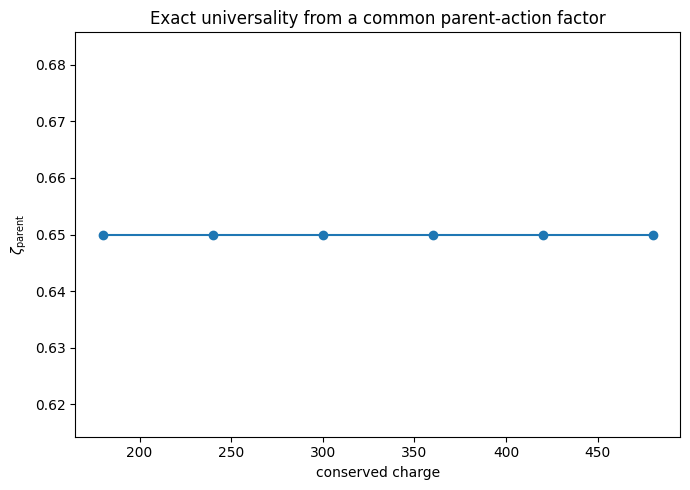

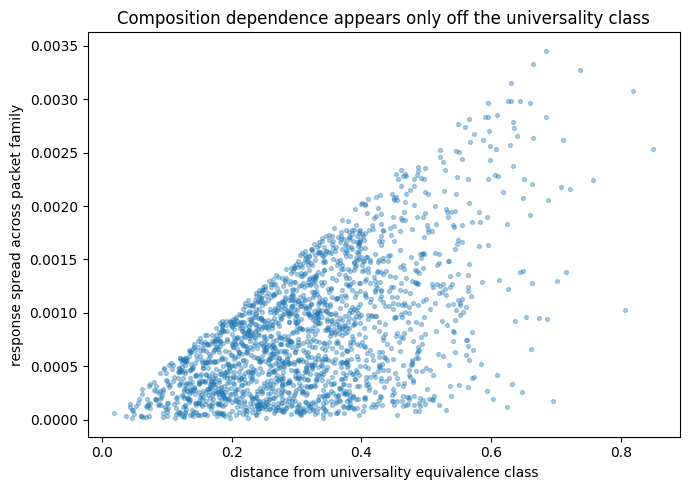

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(TARGETS,zeta_family,'o-')
plt.xlabel('conserved charge')
plt.ylabel(r'$\zeta_{\rm parent}$')
plt.title('Exact universality from a common parent-action factor')
plt.tight_layout()
plt.savefig(FIG/'01_parent_action_universality.png',dpi=180)
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(rand_df.perpendicular_norm,rand_df.perpendicular_spread,s=8,alpha=0.35)
plt.xlabel('distance from universality equivalence class')
plt.ylabel('response spread across packet family')
plt.title('Composition dependence appears only off the universality class')
plt.tight_layout()
plt.savefig(FIG/'02_off_class_nonuniversality.png',dpi=180)
plt.show()

## 12. Summary and exports

In [ ]:
summary_df=pd.DataFrame(summary)
summary_df.to_csv(TAB/'06_summary_tests.csv',index=False)
display(summary_df)

metadata={
    'title':'ECSM V32 — Parent-Action Origin of Universal Matter Coupling',
    'charge_targets':[float(x) for x in TARGETS],
    'zeta0':zeta_parent,
    'parent_action_spread':parent_spread,
    'parent_action_max_error':parent_error,
    'eom_identity_vector':c_eom.tolist(),
    'tests_passed':int(summary_df['pass'].sum()),
    'tests_total':int(len(summary_df))
}
with open(OUT/'metadata.json','w') as f:
    json.dump(metadata,f,indent=2)

(OUT/'README.md').write_text(f'''# ECSM V32 outputs

Common parent-action factor:
A(q) = exp(zeta0 q)

Recovered zeta0:
{zeta_parent:.12f}

Maximum family spread:
{parent_spread:.12e}

Maximum error from input zeta0:
{parent_error:.12e}

Physical universality equivalence class:
w = zeta0 * 1 + b * c_EOM
''')

archive=shutil.make_archive(str(BASE/'ecsm_v32_outputs'),'zip',root_dir=OUT)

print('Passed:',int(summary_df['pass'].sum()),'/',len(summary_df))
print('Parent-action zeta:',zeta_parent)
print('Family spread:',parent_spread)
print('Output archive:',archive)

,test,value,criterion,pass
0,symbolic_common_factor_derivative,zeta0*(E0 + E1 + E2 + E3 + E4),zeta0 * total energy,True
1,symbolic_universal_fractional_response,zeta0,= zeta0,True
2,symbolic_eom_equivalence_class,0,=0,True
3,branch_solution_count,80,>70,True
4,branch_monotonicity,1.696313,>0,True
5,all_packets_converged,6,=6,True
6,fixed_charge_closure,0.0,<1e-6,True
7,positive_packet_energies,181.773918,>0,True
8,parent_action_exact_universality,0.0,<1e-14,True
9,parent_action_recovers_zeta0,0.0,<1e-14,True


Passed: 16 / 16
Parent-action zeta: 0.65
Family spread: 2.220446049250313e-16
Output archive: /mnt/data/ecsm_v32_outputs.zip


## Conclusion

V32 shows that exact universal matter coupling follows naturally when the parent condensate action supplies one common scalar response factor to the complete matter sector:

\[
S_{\rm matter}
=
\int d^4x\,
e^{\zeta_0q}\mathcal L_0.
\]

The radial packet family then obeys

\[
\boxed{
\frac{1}{E_{\rm on}}
\frac{dE_{\rm on}}{dq}
=
\zeta_0
}
\]

independently of charge and internal energy partition.

The more general on-shell equivalence class is

\[
w=\zeta_0\mathbf1+b\,c_{\rm EOM},
\]

but all members represent the same physical response on stationary solutions.

The next unresolved quantity is the value of \(\zeta_0\). V33 should derive it from the parent density-coherence variables

\[
q=\frac{\delta\ln n-\delta\ln\chi}{\sqrt2}
\]

and the scaling dimension of the localised matter action.